1. don't put all code in jupyter notebook
    split into different python files

In [61]:
import pandas as pd
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parents[0]
DATA_DIR = ROOT / "data"

brent_df = pd.read_csv(DATA_DIR / "FUTURE_UK_IFEU_BRNF26.csv")
wti_df = pd.read_csv(DATA_DIR / "FUTURE_US_XNYM_CLF26.csv")
ho_df = pd.read_csv(DATA_DIR / "FUTURE_US_XNYM_HOF26.csv")
go_df = pd.read_csv(DATA_DIR / "FUTURE_UK_IFEU_GASF26.csv")
rb_df = pd.read_csv(DATA_DIR / "FUTURE_US_XNYM_RBF26.csv")

# Dates are different
print(brent_df["Date"].equals(wti_df["Date"]))

# Why dates are different?
'''
1. Different Exchange Holidays: 
    Due to different holiday schedules,
    there might be data for on market but the other
    e.g.,
        ICE (exchange for Brent) may observe a day as holiday,
        while NYMEX (exchange for WTI) may not,
        such as Dec 25, 2023

2. The date format (one may include time)
'''

# Different Exchange Holidays
brent_exist = brent_df["Date"].isin(["12/25/2023"]).any()
wti_exist = wti_df["Date"].isin(["12/25/2023"]).any()
print(brent_exist, wti_exist)

# Different Date Formats
print(brent_df["Date"].dtype == wti_df["Date"].dtype)


False
True False
True


In [62]:
# Data cleaning
# Aligning the Date for graphing and regression

# Change type to datetime
brent_df["Date"] = pd.to_datetime(brent_df["Date"])
wti_df["Date"] = pd.to_datetime(wti_df["Date"])
ho_df["Date"] = pd.to_datetime(ho_df["Date"])
go_df["Date"] = pd.to_datetime(go_df["Date"])
rb_df["Date"] = pd.to_datetime(rb_df["Date"])

# Extract which dates are in common
common_date = (
    set(brent_df["Date"]) &
    set(wti_df["Date"]) &
    set(ho_df["Date"]) &
    set(go_df["Date"]) &
    set(rb_df["Date"])
)

# Update the original dataframes
dfs = [brent_df, wti_df, ho_df, go_df, rb_df]

dfs = [
    df[df["Date"].isin(common_date)]
      .sort_values("Date")
      .reset_index(drop=True)
    for df in dfs
]

brent_df, wti_df, ho_df, go_df, rb_df = dfs

# Now they have exactly same dates
all_equal = all(dfs[0]["Date"].equals(df["Date"]) for df in dfs[1:])
print(all_equal)

# What are these oils?
'''
Brent:
  Brent Crude primarily comes from the North Sea, supplying Europe and other regions. 
  It is one of the most widely used benchmark crudes globally.
  Brent Crude is a light, low-sulfur crude,
  ideal for producing high-quality gasoline and diesel.

WTI:
  WTI Crude primarily comes from Texas in the United States 
  and is the main benchmark crude for the U.S. market.
  WTI Crude is also a light, low-sulfur crude, 
  often used for producing high-quality gasoline and diesel.

Heating oil:
  Heating oil is a refined product from crude oil, 
  primarily used for home heating or industrial heating systems.
  It is a variant of diesel that contains fewer additives and is suitable for heating systems. 
  It is mainly used in cold regions like North America and Europe during the winter months.

Gas oil:
  Gas Oil is a medium-density petroleum product, 
  often used in industrial and heavy transportation applications.
  It is generally heavier than regular diesel 
  and is suitable for heavy machinery, ship engines, and industrial boilers.

RBOB:
  a gasoline blendstock specifically designed to meet environmental standards.
  RBOB is a reformulated gasoline base used to produce low-emission gasoline 
  that meets strict air quality standards, primarily for the U.S. market.
'''

# What differentiates these oils?
'''
1. Light vs. Heavy
  WTI and Brent are light crudes, which are easier to refine.
  They are used to produce high-value products 
  like gasoline and diesel

  Urals and Oman are heavy crudes, which are more complex to refine.
  They require more processes to convert into usable fuels
  like diesel and heay oil

2. Sweet vs. Sour
  WTI and Brent are sweet crudes, which are easier to refine.
  They tend to be more expensive due to less desulfurisation required

  Urals and Oman are sour crudes, which are more complex to refine.
  They tend to be cheaper due to more desulfurisation processes.

3. Refining Products
  Light Crude -> high-quality gasoline, diesel
  Heavy Crude -> heavier products: diesel, fuel oil, asphalt

4. Market and Supply
  WTI and Brent are more suited for U.S. and Europe,
  which require cleaner fuels.

  Urals and Dubai is more common in Asia,
  where there is more demand for heavy fuels,
  and refining facilities are capable of handling heavier crudes.
'''


True


'\n1. Light vs. Heavy\n  WTI and Brent are light crudes, which are easier to refine.\n  They are used to produce high-value products \n  like gasoline and diesel\n\n  Urals and Oman are heavy crudes, which are more complex to refine.\n  They require more processes to convert into usable fuels\n  like diesel and heay oil\n\n2. Sweet vs. Sour\n  WTI and Brent are sweet crudes, which are easier to refine.\n  They tend to be more expensive due to less desulfurisation required\n\n  Urals and Oman are sour crudes, which are more complex to refine.\n  They tend to be cheaper due to more desulfurisation processes.\n\n3. Refining Products\n  Light Crude -> high-quality gasoline, diesel\n  Heavy Crude -> heavier products: diesel, fuel oil, asphalt\n\n4. Market and Supply\n  WTI and Brent are more suited for U.S. and Europe,\n  which require cleaner fuels.\n\n  Urals and Dubai is more common in Asia,\n  where there is more demand for heavy fuels,\n  and refining facilities are capable of handling

               Brent       WTI        HO        GO      RBOB
Date                                                        
2022-11-29  0.004973  0.003364  0.019251  0.001023  0.017031
2022-11-30  0.014311  0.014429  0.029128  0.013283  0.027994
2022-12-01  0.000000  0.000575 -0.017927  0.011429 -0.013493
2022-12-02  0.002373  0.007611 -0.008950 -0.007311 -0.007262
2022-12-05 -0.015128 -0.014821 -0.014083 -0.013057 -0.018537



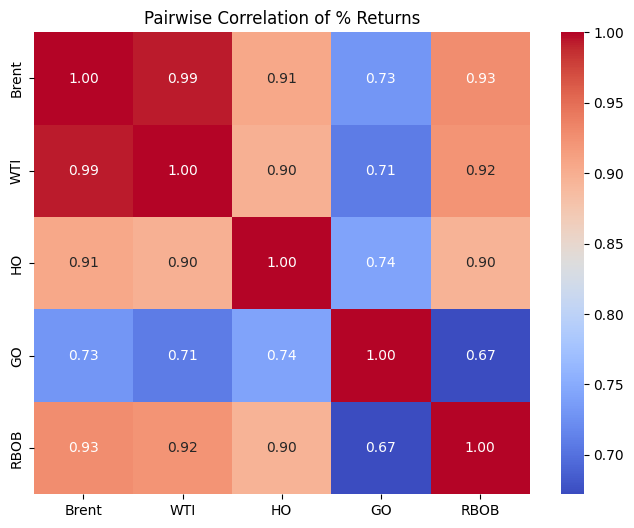

'\nContango is when the futures price of an asset is higher than its current price.\nThis is becasue assests generally rise in value over time,\nand physical commodities have carrying costs.\n\nBackwardation is when the futures price of an asset is lower than its current price.\nThis is due to tight short-term supply, seasonal reason,\nconvenience yield (benefits of holding the commodity, e.g., immediate availability and flexibility)\nhedging pressure (When hedgers sell futures to reduce price risk, they can push futures prices lower.)\n'

In [63]:
# Run pairwise correlation on the % returns 
# and plot this on a heatmap

# Extract close price for each product
brent_price = brent_df[["Date", "Close"]].rename(columns={"Close":"Brent"})
wti_price = wti_df[["Date", "Close"]].rename(columns={"Close":"WTI"})
ho_price = ho_df[["Date", "Close"]].rename(columns={"Close":"HO"})
go_price = go_df[["Date", "Close"]].rename(columns={"Close":"GO"})
rb_price = rb_df[["Date", "Close"]].rename(columns={"Close":"RBOB"})

# Merge data
# Specify merging on date
merged = (
    brent_price.merge(wti_price, on="Date")
               .merge(ho_price, on="Date")
               .merge(go_price, on="Date")
               .merge(rb_price, on="Date")
).set_index("Date")

# Compute % returns
returns = merged.pct_change().dropna()
print(returns.head())
print()
# Correlation matrix
corr = returns.corr()


# Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pairwise Correlation of % Returns")
plt.show()

# Why some of them are correlated
'''
Brent & WTI are highly correlated because they are both global crude benchmarks
influenced by the same macro factors,
such as global supply-demand, geopolitics, OPEC decisions, and USD

RBOB and HO show high correlations with the crudes because curde is their main cost base
and their markets transmit curde shocks quickly into product prices.

In contrast, GO shows lower correlations because it is priced more heavily by region and product-specific forces,
such as European diesel demand, refinary outages, logistics constraints, and regulation.
This means GO can move differently from crude even though it is refined from crude.

Furthermore, RBOB and HO are less influenced by external factors becuase they are traded in
large, liquid and highly integrated U.S. market.
So, external effects can be absorbed by inventories, imports and logistics.
As a result, RBOB and HO tend to move closely with crude oil.
'''

# Future curves: Contango, Backwardation
'''
Contango is when the futures price of an asset is higher than its current price.
This is becasue assests generally rise in value over time,
and physical commodities have carrying costs.

Backwardation is when the futures price of an asset is lower than its current price.
This is due to tight short-term supply, seasonal reason,
convenience yield (benefits of holding the commodity, e.g., immediate availability and flexibility)
hedging pressure (When hedgers sell futures to reduce price risk, they can push futures prices lower.)
'''


In [64]:
from itertools import permutations
from sklearn.linear_model import LinearRegression

results = []
model = LinearRegression()

# Build the pairs
cols = list(returns.columns)
pairs = permutations(cols, 2)

# Why different result when flipped
#   loss is vertical distance
#   so when flipped, you are essentially minising the horizontal distance

# Pairwise Linear Regression
for x_col, y_col in pairs:
    # Implement the model
    # Linear regression requires X to be 2D, so double brackets
    # while y can be 1D
    X = returns[[x_col]].values
    y = returns[y_col].values
    model.fit(X, y)

    # Store parameters
    alpha = model.intercept_
    beta = model.coef_[0]
    r2 = model.score(X, y)
    results.append({
        "y": y_col, "x": x_col,
        "alpha": alpha, "beta": beta, "r2": r2
    })

# click the scale and show the linear regression graph of the two

# Convert to Dataframe and print
results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
print("Top 5 highest R^2:")
print(results_df.head())


# How much unit of WTI does it take to hedge Brent
# Is it truely the reciprocal?
'''
Not reciprocal

Hedge ratios are directional, not reciprocal (A -> B does not mean B -> A)
This is because OLS (Ordinary Least Squares) is asymetric,
it minimises the variance of the dependent variable only.
'''

print(results_df[(results_df["y"]=="Brent") & ((results_df["x"]=="WTI"))])

# Prepare Data for Webpage
# convert to a matrix df using pivot

r2_mat = results_df.pivot(index="y", columns="x", values="r2")

# Add diagonal (self vs self) so heatmap looks complete
for c in r2_mat.index:
    r2_mat.loc[c, c] = 1.0

'''
pivot is used to turn long format into matrix format
it turns the result_df into a matrix
it is helpful in preparing table for heatmap
'''


Top 5 highest R^2:
       y      x     alpha      beta        r2
0    WTI  Brent  0.000020  1.030585  0.985862
1  Brent    WTI -0.000021  0.956604  0.985862
2   RBOB  Brent  0.000155  1.045160  0.859458
3  Brent   RBOB -0.000146  0.822322  0.859458
4    WTI   RBOB -0.000130  0.849584  0.851534
       y    x     alpha      beta        r2
1  Brent  WTI -0.000021  0.956604  0.985862


'\npivot is used to turn long format into matrix format\nit turns the result_df into a matrix\nit is helpful in preparing table for heatmap\n'

In [ ]:
import numpy as np

def portfolio_returns(returns_df, position):
    '''
    potision = {"Brent": 0, "WTI": 0, ...}
    r_port = sum(quantity_i * return_i)
    '''

    q = np.array(list(position.values()), dtype=float) # dim = (5, )
    R = returns_df.to_numpy() # dim = (T, 5)
    return pd.Series(R @ q, index=returns_df.index)

def portfolio_variance(returns_df, position):
    r_port = portfolio_returns(returns_df, position)
    return float(r_port.var())


       y      x     alpha      beta        r2
0    WTI  Brent  0.000020  1.030585  0.985862
1  Brent    WTI -0.000021  0.956604  0.985862
2   RBOB  Brent  0.000155  1.045160  0.859458
3  Brent   RBOB -0.000146  0.822322  0.859458
4    WTI   RBOB -0.000130  0.849584  0.851534

               Brent       WTI        HO        GO      RBOB
Date                                                        
2022-11-29  0.004973  0.003364  0.019251  0.001023  0.017031
2022-11-30  0.014311  0.014429  0.029128  0.013283  0.027994
2022-12-01  0.000000  0.000575 -0.017927  0.011429 -0.013493
2022-12-02  0.002373  0.007611 -0.008950 -0.007311 -0.007262
2022-12-05 -0.015128 -0.014821 -0.014083 -0.013057 -0.018537


In [66]:
SPREAD = {
    "Brent": 0.01,
    "WTI": 0.02,
    "GO": 0.05,
    "HO": 0.10,
    "RBOB": 0.05
}

def hedge_by_variance(
    results_df,
    returns,
    inventory_df,
    exposure_asset,
    exposure_qty,
    top_k=3,
):

    position = inventory_df.set_index("Product")["Quantity"].astype(float).to_dict()

    var_before = portfolio_variance(returns, position)

    candidates = [c for c in returns.columns if c != exposure_asset]

    scored = []
    for hedge_asset in candidates:
        sub = results_df[(results_df["y"] == exposure_asset) & (results_df["x"] == hedge_asset)].iloc[0]

        beta = float(sub["beta"])
        r2 = float(sub["r2"])

        hedge_qty = -beta * float(exposure_qty)

        new_pos = position.copy()
        new_pos[hedge_asset] = float(new_pos[hedge_asset]) + hedge_qty

        var_after = portfolio_variance(returns, new_pos)
        var_change = var_before - var_after

        cost = float(SPREAD[hedge_asset]) * abs(float(hedge_qty))
        score = var_change / cost

        scored.append({
            "hedge_asset": hedge_asset,
            "hedge_qty": hedge_qty,
            "beta": beta,
            "r2": r2,
            "var_before": var_before,
            "var_after": var_after,
            "var_change": var_change,
            "cost": cost,
            "score": score
        })

    scored_df = pd.DataFrame(scored).sort_values("score", ascending=False).head(top_k)

    rows = []
    for _, r in scored_df.iterrows():
        qty = float(r["hedge_qty"])
        action = "BUY" if qty > 0 else "SELL"
        rows.append({
            "hedge_product": r["hedge_asset"],
            "action": action,
            "hedge_qty": round(abs(qty), 4),
            "beta": round(float(r["beta"]), 6),
            "r2": round(float(r["r2"]), 6),
            "var_after": round(float(r["var_after"]), 10),
            "var_change": round(float(r["var_change"]), 10),
            "cost": round(float(r["cost"]), 6),
            "score": round(float(r["score"]), 10),
        })

    best = scored_df.iloc[0]
    best_asset = str(best["hedge_asset"])
    best_qty = float(best["hedge_qty"])
    best_action = "BUY" if best_qty > 0 else "SELL"

    summary_text = (
        f"Exposure {exposure_qty:+g} units of {exposure_asset}. "
        f"Best hedge (max variance reduction per cost): {best_action} {abs(best_qty):.4f} units of {best_asset}. "
        f"Var before={best['var_before']:.6g}, Var after={best['var_after']:.6g}, "
        f"ΔVar={best['var_change']:.6g}, cost={best['cost']:.6g}."
    )

    return rows, summary_text

In [ ]:
# http://127.0.0.1:8050/

# Find hedging strategy by calculating previous variance (last year) for portfolio
# do a loop for all of them, using betas to calculate how many units should you hedge for each asset
# append to dictionary
# dictionary has the asset (key) and variance of portfolio
# pick the one that leads to lowest variance

# variance reduction per cost(dollar)
# cost is the amount of spread you have to pay
# import the spread

# The spreads:
# Brent: 1 cent, WTI: 2 cents, GO: 5 cents, HO: 10 cents, RBOB: 5 cents

import numpy as np
from dash import Dash, html, dcc, Input, Output, State
import dash_table
import plotly.express as px
import plotly.graph_objects as go

DISPLAY = {
    "Brent": "Brent",
    "WTI": "WTI",
    "GO": "Gas Oil",
    "RBOB": "RBOB",
    "HO": "Heating Oil",
}

TICKERS = ["Brent", "WTI", "HO", "GO", "RBOB"]

SPREAD = {
    "Brent": 0.01,
    "WTI": 0.02,
    "GO": 0.05,
    "HO": 0.10,
    "RBOB": 0.05
}

# Set up R2 Figure
r2_fig = px.imshow(
    r2_mat,
    text_auto=".3f",
    aspect="auto",
    title="R2 Heatmap"
)

# Inventory data and table
inventory_df = pd.DataFrame({
    'Product': TICKERS,
    'Quantity': [0, 0, 0, 0, 0]
})

inventory_table = dash_table.DataTable(
    id='inventory-table',
    columns=[{'name': col, 'id': col} for col in inventory_df.columns],
    data=inventory_df.to_dict('records'),
)


app = Dash()

app.layout = html.Div([
    html.H1("Commodity Hedging Strategy"),

    html.Div([
        html.Label("Enter your trade:"),
        dcc.Dropdown(
            id='commodity-dropdown',
            options=[{"label": DISPLAY[t], "value": t} for t in TICKERS],
            placeholder="Select a Commodity"
        ),
        dcc.Input(id='quantity-input', type='number', placeholder='Quantity'),
        html.Button("Submit Trade", id='submit-trade')
    ]),

    html.Div([
        html.H2("Current Inventory"),
        inventory_table
    ]),

    html.Div([
        dcc.ConfirmDialog(
            id='success-dialog',
            message='Trade Submitted Successfully!',
            displayed=False
        ),
        dcc.ConfirmDialog(
            id='fail-dialog',
            message='Invalid Input',
            displayed=False
        )
    ]),

    html.H2("Hedge Suggestion"),
    html.Div(id="hedge-summary", children="", style={
        "padding": "10px",
        "border": "1px solid #ddd",
        "borderRadius": "8px",
        "marginBottom": "10px"
    }),
    dash_table.DataTable(
        id="hedge-table",
        columns=[
            {"name": "Hedge Product", "id": "hedge_product"},
            {"name": "Action", "id": "action"},
            {"name": "Hedge Qty", "id": "hedge_qty"},
            {"name": "Beta", "id": "beta"},
            {"name": "R2", "id": "r2"},
            {"name": "Var After", "id": "var_after"},
            {"name": "ΔVar", "id": "var_change"},
            {"name": "Cost", "id": "cost"},
            {"name": "Score", "id": "score"},
        ],
        data=[],
        style_cell={"padding": "6px"}
    ),


    html.H2("Hedging Heatmap"),
    html.Div([
        dcc.Graph(id="r2-heatmap", figure=r2_fig),
    ]),

    html.H2("Regression Plot"),
    html.Div([
        dcc.Graph(
            id="regression-plot",
            figure=go.Figure().update_layout(
                title="Click a heatmap cell to show regression"
            )
        )
    ]),
])


# Dash Callback
@app.callback(
    Output('inventory-table', 'data'),
    Output('hedge-summary', 'children'),
    Output('hedge-table', 'data'),
    Output('commodity-dropdown', 'value'),
    Output('quantity-input', 'value'),
    Output('success-dialog', 'displayed'),
    Output('fail-dialog', 'displayed'),

    Input('submit-trade', 'n_clicks'),
    State('commodity-dropdown', 'value'),
    State('quantity-input', 'value')
)
def update_inventory_hedge(n_clicks, exposure_asset, exposure_qty):
    # Check for click
    if n_clicks is None:
        return inventory_df.to_dict('records'), "", [], None, None, False, False
    
    # Check for commodity and quatity input
    if exposure_asset is None or exposure_qty is None or exposure_qty == 0:
        return inventory_df.to_dict('records'), "Invalid input!", [], None, None, False, True
    
    # update inventory
    inventory_df.loc[inventory_df['Product']==exposure_asset, 'Quantity'] += exposure_qty

    # compute hedge table
    rows, hedge_text = hedge_by_variance(results_df, returns, inventory_df, exposure_asset, exposure_qty, top_k=3)

    return inventory_df.to_dict("records"), hedge_text, rows, None, None, True, False

# Call back for Heapmap to show regression
@app.callback(
    Output("regression-plot", "figure"),
    Input("r2-heatmap", "clickData"),
)
def show_regression_plot(clickData):
    # clickData is a JSON (Python dict)
    if not clickData:
        return go.Figure().update_layout(
            title="Click a heatmap cell to show regression"
        )
    print(clickData)
    pt = clickData["points"][0]
    x_col = pt["x"]
    y_col = pt["y"]

    x_product = DISPLAY[x_col]
    y_product = DISPLAY[y_col]

    if x_col == y_col:
        return go.Figure().update_layout(title=f"Please click an off-diagonal cell")
    
    row = results_df[(results_df["x"]==x_col) & (results_df["y"]==y_col)].iloc[0]
    alpha = row["alpha"]
    beta = row["beta"]
    r2 = row["r2"]

    x = returns[x_col].to_numpy()
    y = returns[y_col].to_numpy()
    y_hat = alpha + beta * x

    order = np.argsort(x)
    x_sorted = x[order]
    yhat_sorted = y_hat[order]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=x, y=y,
        mode="markers",
        name="Returns"
    ))
    fig.add_trace(go.Scatter(
        x=x_sorted, y=yhat_sorted,
        mode="lines",
        name="Fit Line"
    ))
    fig.update_layout(
        title=f"Linear Regression: {y_product} vs {x_product} "
              f"(beta={beta:.5f}, intercept={alpha:.5g}, R^2={r2:.5f})",
        xaxis_title=f"{x_product} returns",
        yaxis_title=f"{y_product} returns",
        height=450,
        margin=dict(l=40, r=20, t=60, b=40),
    )
    return fig
    
app.server.config["PROPAGATE_EXCEPTIONS"] = True
if __name__ == "__main__":
    app.run(debug=True)


Product     object
Quantity     int64
dtype: object
